In [1]:
import os

# This forces TensorFlow to use the internal Keras 2 instead of the new Keras 3
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Transfer Learning with TensorFlow Part 3: Scaling up (🍔👁 Food Vision mini)

In the previous two notebooks, we've seen the power of transfer learning.

Now we know our smaller modelling experiments are working, it's time to step things up a notch with more data.

This is a common practice in machine learning and deep learning: get a model working on a small amount of data before scaling it up to a larger amount of data.

It's time to get closer to our Food Vision project coming to life. In this notebook we're going to scale up from using 10 classes of the Food101 data to using all of the classes in the Food101 dataset.

Our goal is to **beat the original [Food101 paper](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf)'s results with 10% of data**.

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/06-ml-serial-experimentation.png)
*Machine learning practitioners are serial experimenters. Start small, get a model working, see if your experiments work then gradually scale them up to where you want to go (we're going to be looking at scaling up throughout this notebook).*

## What we're going to cover

We're going to go through the follow with TensorFlow:

- Downloading and preparing 10% of the Food101 data (10% of training data)
- Training a feature extraction transfer learning model on 10% of the Food101 training data
- Fine-tuning our feature extraction model
- Saving and loaded our trained model
- Evaluating the performance of our Food Vision model trained on 10% of the training data
  - Finding our model's most wrong predictions
- Making predictions with our Food Vision model on custom images of food.

In [2]:
# Getting Helper Functions:

import wget

# Run commands below if the helper_functions.py file is not already downloded:
#url = 'https://raw.githubusercontent.com/Shailya777/Learning-Logs/refs/heads/main/Deep_Learning_with_Tensorflow/helper_functions.py'
#file = wget.download(url)

In [4]:
from helper_functions import create_tensorboard_callback
from helper_functions import plot_loss_curves
from helper_functions import unzip_data
from helper_functions import compare_historys
from helper_functions import walk_through_dir

## 101 Food Classes: Working with less data

So far we've confirmed the transfer learning model's we've been using work pretty well with the 10 Food Classes dataset. Now it's time to step it up and see how they go with the full 101 Food Classes.

In the original [Food101](https://www.kaggle.com/dansbecker/food-101) dataset there's 1000 images per class (750 of each class in the training set and 250 of each class in the test set), totalling 101,000 imags.

We could start modelling straight away on this large dataset but in the spirit of continually experimenting, we're going to see how our previously working model's go with 10% of the training data.

This means for each of the 101 food classes we'll be building a model on 75 training images and evaluating it on 250 test images.

In [5]:
# Getting Data:

# Run commands below if Dataset is not already downloaded:
#url = 'https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip'
#file = wget.download(url)

In [6]:
# Unzipping The Data:

# Run command below if dataset is not already unzipped:
#unzip_data('101_food_classes_10_percent.zip')

In [7]:
# Walking Through Directory of Data:
walk_through_dir('101_food_classes_10_percent')

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/train'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/cheese_plate'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/beignets'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/donuts'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/seaweed_salad'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/french_fries'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/tacos'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/poutine'.
There are 0 directories and 75 images in '101_food_classes_10_perc

In [8]:
# Setting up Training and Test Data Directory Paths:

train_dir = '101_food_classes_10_percent/train/'
test_dir = '101_food_classes_10_percent/test/'

In [9]:
# Importing Necessary Libraries:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomHeight, RandomWidth, Rescaling
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.models import Sequential

import warnings
warnings.filterwarnings('ignore')

In [11]:
# Setting up Data Loaders for the Model:

IMG_SHAPE = (224,224)

train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory= train_dir,
                                                                               image_size= IMG_SHAPE,
                                                                               label_mode= 'categorical',
                                                                               batch_size= 32)

test_data = tf.keras.preprocessing.image_dataset_from_directory(directory= test_dir,
                                                               image_size= IMG_SHAPE,
                                                               label_mode= 'categorical',
                                                               batch_size= 32,
                                                               shuffle= False) # Not Shuffling Test Data For Prediction Analysis

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


## Train a big model with transfer learning on 10% of 101 food classes

Our food image data has been imported into TensorFlow, time to model it.

To keep our experiments swift, we're going to start by using feature extraction transfer learning with a pre-trained model for a few epochs and then fine-tune for a few more epochs.

More specifically, our goal will be to see if we can beat the baseline from original [Food101 paper](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf) (50.76% accuracy on 101 classes) with 10% of the training data and the following modelling setup:
* A [`ModelCheckpoint`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint) callback to save our progress during training, this means we could experiment with further training later without having to train from scratch every time
* Data augmentation built right into the model
* A headless (no top layers) [`EfficientNetB0`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB0) architecture from `tf.keras.applications` as our base model
* A `Dense` layer with 101 hidden neurons (same as number of food classes) and softmax activation as the output layer
* Categorical crossentropy as the loss function since we're dealing with more than two classes
* The Adam optimizer with the default settings
* Fitting for 5 full passes on the training data while evaluating on 15% of the test data


Let's start by creating the `ModelCheckpoint` callback. 

Since we want our model to perform well on unseen data we'll set it to monitor the validation accuracy metric and save the model weights which score the best on that.

In [13]:
# Creating a Model Checkpoint Callback:

checkpoint_path = '101_classes_10_percent_data_model_checkpoint'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath= checkpoint_path,
                                                        monitor= 'val_accuracy', # save the model weights which score the best validation accuracy
                                                        save_weights_only= True, # save only the model weights
                                                        save_best_only= True) # only keep the best model weights on file (delete the rest)

In [14]:
# Creating a Sequential Model for Data Augmentation:

data_augmentation = Sequential(name= 'Data_Augmentation')
data_augmentation.add(RandomFlip(mode= 'horizontal'))
data_augmentation.add(RandomRotation(factor= 0.2))
data_augmentation.add(RandomZoom(height_factor= 0.2))
data_augmentation.add(RandomHeight(factor= 0.2))
data_augmentation.add(RandomWidth(factor= 0.2))
#data_augmentation.add(Rescaling(scale= 1/255)) # keep for ResNet50V2, remove for EfficientNetB0

In [15]:
# Creating The Model using efficientnet_v2.EfficientNetV2B0:

# Setting Up Base Model and Freezing it's Layers (Feature Extraction):
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top= False)
base_model.trainable= False

# Setting Up Model Architecture:
inputs = Input(shape= (224, 224, 3), name= 'Input_Layer') # shape of input image
x = data_augmentation(inputs) # augment images (only happens during training)
x = base_model(x, training= False) # put the base model in inference mode so we can use it to extract features without updating the weights
x = GlobalAveragePooling2D(name= 'Global_Average_Pooling_Layer')(x) # pool the outputs of the base model
outputs = Dense(units= 101, activation= 'softmax', name= 'Output_Layer')(x) # same number of outputs as classes (101)

model = Model(inputs, outputs)

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/06-efficientnetb0-feature-extractor-with-dense-layer-on-top.png)
*A colourful figure of the model we've created with: 224x224 images as input, data augmentation as a layer, EfficientNetB0 as a backbone, an averaging pooling layer as well as dense layer with 101 neurons (same as number of classes we're working with) as output.*

In [16]:
# Summary of The Model:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_Layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 Data_Augmentation (Sequent  (None, None, None, 3)     0         
 ial)                                                            
                                                                 
 efficientnetv2-b0 (Functio  (None, None, None, 1280   5919312   
 nal)                        )                                   
                                                                 
 Global_Average_Pooling_Lay  (None, 1280)              0         
 er (GlobalAveragePooling2D                                      
 )                                                               
                                                                 
 Output_Layer (Dense)        (None, 101)               129381

Notice the number of trainable and non-trainable parameters. It seems the only trainable parameters are within the `output_layer` which is exactly what we're after with this first run of feature extraction; keep all the learned patterns in the base model (`EfficientNetb0`) frozen whilst allowing the model to tune its outputs to our custom data.

In [17]:
# Compiling The Model:
model.compile(optimizer= Adam(),
             loss= CategoricalCrossentropy(),
             metrics= ['accuracy'])

In [18]:
# Fitting The Model on Data:

history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                          validation_data= test_data,
                                          epochs= 5,
                                          validation_steps= int(0.15 * len(test_data)), # Validate on 15% of Test Data During Training
                                          callbacks= [checkpoint_callback])

Epoch 1/5


2026-01-22 13:12:36.704708: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


  1/237 [..............................] - ETA: 16:51 - loss: 4.7975 - accuracy: 0.0625

2026-01-22 13:12:37.458567: I external/local_xla/xla/service/service.cc:163] XLA service 0x7174087418f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-22 13:12:37.458594: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-01-22 13:12:37.463583: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769087557.543426    5968 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


237/237 [==============================] - 67s 268ms/step - loss: 3.5256 - accuracy: 0.2442 - val_loss: 2.6854 - val_accuracy: 0.4243
Epoch 2/5
237/237 [==============================] - 53s 223ms/step - loss: 2.4289 - accuracy: 0.4461 - val_loss: 2.2108 - val_accuracy: 0.4838
Epoch 3/5
237/237 [==============================] - 44s 187ms/step - loss: 2.0373 - accuracy: 0.5150 - val_loss: 1.9925 - val_accuracy: 0.5101
Epoch 4/5
237/237 [==============================] - 40s 168ms/step - loss: 1.8357 - accuracy: 0.5510 - val_loss: 1.8800 - val_accuracy: 0.5291
Epoch 5/5
237/237 [==============================] - 35s 146ms/step - loss: 1.6933 - accuracy: 0.5852 - val_loss: 1.8139 - val_accuracy: 0.5373


In [19]:
# Evaluating The Model on Full Test Data:

results_feature_extraction_model = model.evaluate(test_data)

790/790 [==============================] - 16s 20ms/step - loss: 1.6254 - accuracy: 0.5707


Well it looks like **we just beat our baseline (the results from the original Food101 paper) with 10% of the data**! In around 5-minutes. that's the power of deep learning and more precisely, transfer learning: leveraging what one model has learned on another dataset for our own dataset.

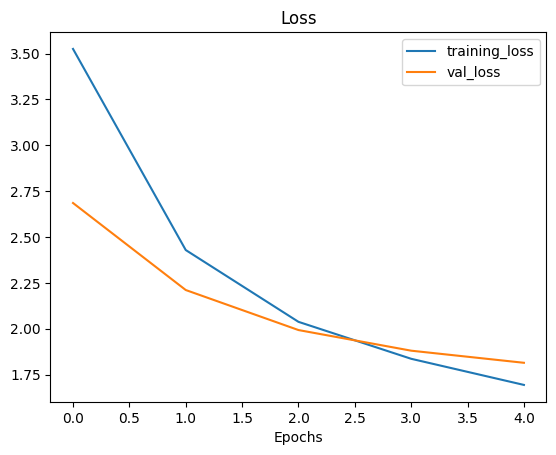

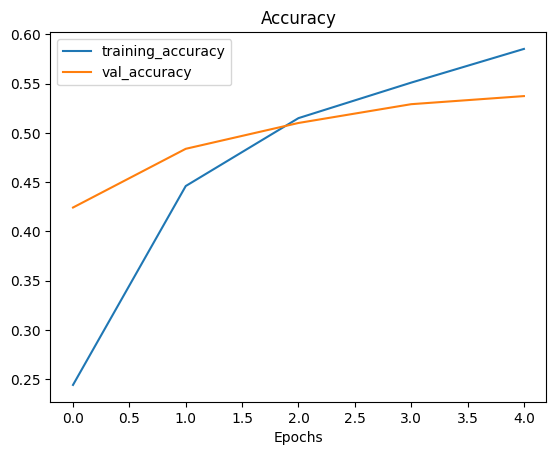

In [20]:
# Plotting Loss and Accuracy Curves:
plot_loss_curves(history= history_all_classes_10_percent)

Ideally, the two curves should be very similar to each other, if not, there may be some overfitting or underfitting.

## Fine-tuning

Our feature extraction transfer learning model is performing well. Why don't we try to fine-tune a few layers in the base model and see if we gain any improvements?

The good news is, thanks to the `ModelCheckpoint` callback, we've got the saved weights of our already well-performing model so if fine-tuning doesn't add any benefits, we can revert back.

To fine-tune the base model we'll first set its `trainable` attribute to `True`, unfreezing all of the frozen.

Then since we've got a relatively small training dataset, we'll refreeze every layer except for the last 5, making them trainable.

In [21]:
# Unfreezing all the Layers of The Base Model:
base_model.trainable = True

# Freezing all Layers of Base Model except last 5:
for layer in base_model.layers[:-5]:
    layer.trainable = False

In [22]:
# Checking Layers of Base Model:

for layer_number, layer in enumerate(base_model.layers):
    print(f'Layer Number: {layer_number} | Layer Name: {layer.name} | Trainable?: {layer.trainable}')

Layer Number: 0 | Layer Name: input_1 | Trainable?: False
Layer Number: 1 | Layer Name: rescaling | Trainable?: False
Layer Number: 2 | Layer Name: normalization | Trainable?: False
Layer Number: 3 | Layer Name: stem_conv | Trainable?: False
Layer Number: 4 | Layer Name: stem_bn | Trainable?: False
Layer Number: 5 | Layer Name: stem_activation | Trainable?: False
Layer Number: 6 | Layer Name: block1a_project_conv | Trainable?: False
Layer Number: 7 | Layer Name: block1a_project_bn | Trainable?: False
Layer Number: 8 | Layer Name: block1a_project_activation | Trainable?: False
Layer Number: 9 | Layer Name: block2a_expand_conv | Trainable?: False
Layer Number: 10 | Layer Name: block2a_expand_bn | Trainable?: False
Layer Number: 11 | Layer Name: block2a_expand_activation | Trainable?: False
Layer Number: 12 | Layer Name: block2a_project_conv | Trainable?: False
Layer Number: 13 | Layer Name: block2a_project_bn | Trainable?: False
Layer Number: 14 | Layer Name: block2b_expand_conv | Traina

Because we're fine-tuning, we'll use a 10x lower learning rate to ensure the updates to the previous trained weights aren't too large.

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/06-lowering-the-learning-rate.png)
*When fine-tuning and unfreezing layers of your pre-trained model, it's common practice to lower the learning rate you used for your feature extraction model. How much by? A 10x lower learning rate is usually a good place to to start.*

In [23]:
# Recompiling The Model with Lower Leraning Rate:
model.compile(optimizer= Adam(learning_rate= 0.0001),
             loss= CategoricalCrossentropy(),
             metrics= ['accuracy'])

In [24]:
# Fitting The Model for 5 More epochs for Fine Tuning:

fine_tune_epochs = 10 # Model has already done 5 epochs (Feature Extraction), this is the total number of epochs we're after (5+5=10)

history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                    validation_data= test_data,
                                                    epochs= fine_tune_epochs,
                                                    initial_epoch= history_all_classes_10_percent.epoch[-1], # start from previous last epoch
                                                    validation_steps= int(0.15 * len(test_data))) # validate on 15% of the test data

Epoch 5/10
237/237 [==============================] - 86s 352ms/step - loss: 1.4786 - accuracy: 0.6292 - val_loss: 1.7506 - val_accuracy: 0.5381
Epoch 6/10
237/237 [==============================] - 57s 242ms/step - loss: 1.3719 - accuracy: 0.6392 - val_loss: 1.7096 - val_accuracy: 0.5469
Epoch 7/10
237/237 [==============================] - 45s 188ms/step - loss: 1.3086 - accuracy: 0.6620 - val_loss: 1.7321 - val_accuracy: 0.5424
Epoch 8/10
237/237 [==============================] - 41s 175ms/step - loss: 1.2642 - accuracy: 0.6659 - val_loss: 1.6942 - val_accuracy: 0.5527
Epoch 9/10
237/237 [==============================] - 37s 158ms/step - loss: 1.2382 - accuracy: 0.6780 - val_loss: 1.6968 - val_accuracy: 0.5516
Epoch 10/10
237/237 [==============================] - 31s 131ms/step - loss: 1.2154 - accuracy: 0.6742 - val_loss: 1.6926 - val_accuracy: 0.5596


In [25]:
# Evaluating The Model on Full Test Data:
results_all_classes_10_percent_fine_tune = model.evaluate(test_data)

790/790 [==============================] - 17s 21ms/step - loss: 1.4815 - accuracy: 0.6034


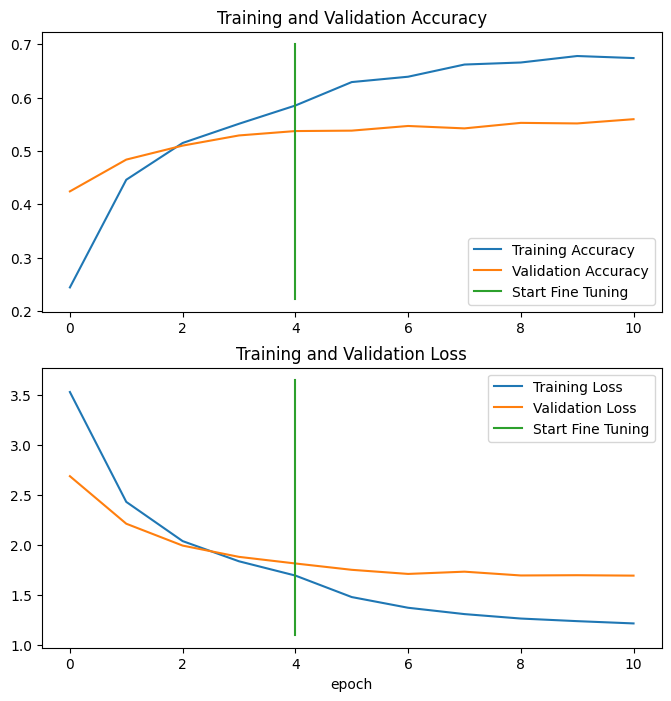

In [26]:
# Comparing Model Loss and Accuracy Before and After Fine Tuning:

compare_historys(original_history= history_all_classes_10_percent,
                new_history= history_all_classes_10_percent_fine_tune,
                initial_epochs= 5)

It seems that after fine-tuning, our model's training metrics improved significantly but validation, not so much. Looks like our model is starting to overfit. 

This is okay though, its very often the case that fine-tuning leads to overfitting when the data a pre-trained model has been trained on is similar to your custom data.

In our case, our pre-trained model, `EfficientNetB0` was trained on [ImageNet](http://www.image-net.org/index) which contains many real life pictures of food just like our food dataset.

If feautre extraction already works well, the improvements you see from fine-tuning may not be as great as if your dataset was significantly different from the data your base model was pre-trained on.

### Saving our trained model

To prevent having to retrain our model from scratch, let's save it to file using the [`save()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#save) method.

In [27]:
# Saving The Fine Tuned Model:

model.save(filepath= 'all_classes_10_percent_fine_tune_model')

INFO:tensorflow:Assets written to: all_classes_10_percent_fine_tune_model/assets


INFO:tensorflow:Assets written to: all_classes_10_percent_fine_tune_model/assets


## Loading and Evaluating the performance of the big dog model across all different classes

We've got a trained and saved model which according to the evaluation metrics we've used is performing fairly well.

Let's dive a little deeper into our model's performance and get some visualizations going.

To do so, we'll load in the saved model and use it to make some predictions on the test dataset.

Evaluating a machine learning model is as important as training one. Metrics can be deceiving. You should always visualize your model's performance on unseen data to make sure you aren't being fooled by good looking training numbers.

In [28]:
# Loading back the Saved Model:

loaded_model = tf.keras.models.load_model('all_classes_10_percent_fine_tune_model')

In [29]:
# Summary of Loaded Model:

loaded_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_Layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 Data_Augmentation (Sequent  (None, None, None, 3)     0         
 ial)                                                            
                                                                 
 efficientnetv2-b0 (Functio  (None, None, None, 1280   5919312   
 nal)                        )                                   
                                                                 
 Global_Average_Pooling_Lay  (None, 1280)              0         
 er (GlobalAveragePooling2D                                      
 )                                                               
                                                                 
 Output_Layer (Dense)        (None, 101)               129381

### Making predictions with our trained model

To evaluate our trained model, we need to make some predictions with it and then compare those predictions to the test dataset.

Because the model has never seen the test dataset, this should give us an indication of how the model will perform in the real world on data similar to what it has been trained on.

To make predictions with our trained model, we can use the `predict()` method passing it the test data.

Since our data is multi-class, doing this will return a prediction probability tensor for each sample.

In other words, every time the trained model see's an image it will compare it to all of the patterns it learned during training and return an output for every class (all 101 of them) of how likely the image is to be that class.

In [30]:
pred_prob = loaded_model.predict(test_data)

790/790 [==============================] - 14s 17ms/step


In [31]:
pred_prob.shape

(25250, 101)

What we've got is often referred to as a **predictions probability tensor** (or array).

In [32]:
# Looking at prediction od one sample:
pred_prob[0]

array([4.7214045e-03, 2.4588900e-05, 1.0666691e-01, 6.5110089e-07,
       3.6719939e-05, 2.2695528e-04, 1.4644595e-05, 2.0532671e-05,
       8.9577743e-04, 4.4521326e-04, 8.7889748e-06, 2.7532276e-05,
       2.8598923e-04, 6.4232154e-05, 1.7194923e-02, 3.1921808e-02,
       3.8559880e-04, 1.7829264e-03, 5.3647002e-03, 6.6849345e-04,
       1.7529593e-03, 2.7455973e-05, 6.3418411e-05, 3.8833248e-05,
       5.9757891e-05, 3.6708494e-03, 2.3827062e-03, 6.4756896e-06,
       8.5319094e-03, 2.0054745e-04, 2.1203980e-06, 9.1245084e-04,
       3.2110217e-03, 2.0254042e-04, 3.9590099e-03, 6.1972671e-05,
       8.7771716e-04, 8.9847512e-04, 4.7818366e-02, 7.1449351e-04,
       1.2121164e-03, 7.3592790e-04, 4.8921807e-05, 1.6985023e-04,
       1.5103766e-04, 8.9799752e-05, 2.3451002e-04, 3.2556505e-04,
       7.8834622e-05, 1.7233420e-02, 1.3675750e-03, 1.4492130e-03,
       6.9448829e-02, 1.6443953e-02, 5.1292332e-06, 1.7794236e-03,
       1.0335667e-03, 3.8191819e-04, 1.3575332e-03, 2.4563375e

In [33]:
# We get One Prediction Probability Per Class, in Our Case, 101 Classes:

print(f'Number of Prediction Probabilities for Sample 0: {len(pred_prob[0])}\n')
print(f'What Prediction Probability Sample 0 looks like:\n {pred_prob[0]}\n')
print(f'The Class with The Highest Predicted Probability by The Model for Sample 0: {pred_prob[0].argmax()}')

Number of Prediction Probabilities for Sample 0: 101

What Prediction Probability Sample 0 looks like:
 [4.7214045e-03 2.4588900e-05 1.0666691e-01 6.5110089e-07 3.6719939e-05
 2.2695528e-04 1.4644595e-05 2.0532671e-05 8.9577743e-04 4.4521326e-04
 8.7889748e-06 2.7532276e-05 2.8598923e-04 6.4232154e-05 1.7194923e-02
 3.1921808e-02 3.8559880e-04 1.7829264e-03 5.3647002e-03 6.6849345e-04
 1.7529593e-03 2.7455973e-05 6.3418411e-05 3.8833248e-05 5.9757891e-05
 3.6708494e-03 2.3827062e-03 6.4756896e-06 8.5319094e-03 2.0054745e-04
 2.1203980e-06 9.1245084e-04 3.2110217e-03 2.0254042e-04 3.9590099e-03
 6.1972671e-05 8.7771716e-04 8.9847512e-04 4.7818366e-02 7.1449351e-04
 1.2121164e-03 7.3592790e-04 4.8921807e-05 1.6985023e-04 1.5103766e-04
 8.9799752e-05 2.3451002e-04 3.2556505e-04 7.8834622e-05 1.7233420e-02
 1.3675750e-03 1.4492130e-03 6.9448829e-02 1.6443953e-02 5.1292332e-06
 1.7794236e-03 1.0335667e-03 3.8191819e-04 1.3575332e-03 2.4563375e-05
 4.8536094e-07 3.7252071e-04 2.9311897e-03 5

for each image tensor we pass to our model, because of the number of output neurons and activation function in the last layer (`layers.Dense(len(train_data_all_10_percent.class_names), activation="softmax"`), it outputs a prediction probability between 0 and 1 for all each of the 101 classes.

And the index of the highest prediction probability can be considered what the model thinks is the most likely label. Similarly, the lower prediction probaiblity value, the less the model thinks that the target image is that specific class.

Due to the nature of the softmax activation function, the sum of each of the prediction probabilities for a single sample will be 1 (or at least very close to 1). E.g. `pred_probs[0].sum() = 1`.

We can find the index of the maximum value in each prediction probability tensor using the `argmax()` method.

In [34]:
# Getting Class Prediction fro Every Prediction Array:
pred_class = pred_prob.argmax(axis= 1)

In [35]:
pred_class[:10]

array([85,  0,  0,  8,  8, 78, 29, 46,  2, 41])

We've now got the predicted class index for each of the samples in our test dataset.

We'll be able to compare these to the test dataset labels to further evaluate our model.

To get the test dataset labels we can unravel our `test_data` object (which is in the form of a `tf.data.Dataset`) using the [`unbatch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#unbatch) method.

Doing this will give us access to the images and labels in the test dataset. Since the labels are in one-hot encoded format, we'll take use the `argmax()` method to return the index of the label.

This unravelling is why we `shuffle=False` when creating the test data object. Otherwise, whenever we loaded the test dataset (like when making predictions), it would be shuffled every time, meaning if we tried to compare our predictions to the labels, they would be in different orders.

In [36]:
# Unraveling test_data Batch Dataset:

y_lables = []

for images, labels in test_data.unbatch(): # unbatch the test data and get images and labels
    y_lables.append(labels.numpy().argmax()) # append the index which has the largest value (labels are one-hot)

y_lables[:10]

2026-01-22 13:23:53.260439: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]